## Daily Challenge: Text Analysis of Books using Word Cloud

### Text Preprocessing

In [ ]:
import requests
import re
from bs4 import BeautifulSoup

# URLs for the books (Project Gutenberg versions are commonly used for such exercises)
book_urls = {
    "Alice's Adventures in Wonderland": "https://www.gutenberg.org/files/11/11-0.txt",
    "Through the Looking-Glass": "https://www.gutenberg.org/files/12/12-0.txt",
    "A Tangled Tale": "https://www.gutenberg.org/files/3090/3090-0.txt"
}

def load_texts(urls):
    corpus = {}
    for title, url in urls.items():
        print(f"Loading {title} from {url}...")
        try:
            response = requests.get(url)
            response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
            raw_text = response.text

            # Remove irrelevant parts (autoral credits, headers, footers) FIRST,
            # before aggressive whitespace cleaning, to preserve newline structure for slicing.
            # Using the markers as described in the problem hint, with a slight adjustment for the full Project Gutenberg boilerplate lines.
            # The prompt hints for ' START' and ' END'. The Project Gutenberg files contain lines like:
            # "*** START OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"
            # "*** END OF THE PROJECT GUTENBERG EBOOK ALICE'S ADVENTURES IN WONDERLAND ***"
            start_marker = '*** START' # Part of the full start boilerplate line
            end_marker = '*** END'   # Part of the full end boilerplate line

            start_index = raw_text.find(start_marker)
            end_index = raw_text.rfind(end_marker)

            text_content_after_slicing = raw_text

            if start_index != -1 and end_index != -1 and end_index > start_index:
                # Find the newline *after* the full start boilerplate line
                # This ensures we skip the entire boilerplate line.
                # We need to find the newline *after* the point where the start marker itself ends.
                start_of_actual_content_idx = raw_text.find('\n', start_index + len(start_marker))
                if start_of_actual_content_idx == -1:
                    start_of_actual_content_idx = start_index + len(start_marker) # Fallback if no newline after marker
                else:
                    start_of_actual_content_idx += 1 # Start after the newline

                # Find the newline *before* the full end boilerplate line
                # This ensures we stop *before* the boilerplate line.
                end_of_actual_content_idx = raw_text.rfind('\n', 0, end_index)

                # Ensure indices are valid and in order
                if start_of_actual_content_idx < end_of_actual_content_idx:
                    text_content_after_slicing = raw_text[start_of_actual_content_idx:end_of_actual_content_idx]

            # Now, apply cleaning (remove non-words, normalize whitespace)
            # This regex keeps letters, numbers, and basic punctuation, but replaces others with a space.
            # It explicitly keeps newlines for now in `cleaned_text_pre_whitespace`.
            cleaned_text_pre_whitespace = re.sub(r'[^a-zA-Z0-9.,\s\[\]\(\)\'\"\&]', ' ', text_content_after_slicing)

            # Replace multiple whitespace characters (including newlines) with a single space
            # and then strip leading/trailing spaces. This converts all text to a single continuous string.
            final_cleaned_text = re.sub(r'\s+', ' ', cleaned_text_pre_whitespace).strip()

            corpus[title] = final_cleaned_text
            print(f"Successfully loaded and cleaned '{title}'.")
        except requests.exceptions.RequestException as e:
            print(f"Error loading {title}: {e}")
            corpus[title] = ""
    return corpus

# Load the texts
book_corpus = load_texts(book_urls)


Loading Alice's Adventures in Wonderland from https://www.gutenberg.org/files/11/11-0.txt...
Successfully loaded and cleaned 'Alice's Adventures in Wonderland'.
Loading Through the Looking-Glass from https://www.gutenberg.org/files/12/12-0.txt...
Successfully loaded and cleaned 'Through the Looking-Glass'.
Loading A Tangled Tale from https://www.gutenberg.org/files/3090/3090-0.txt...
Successfully loaded and cleaned 'A Tangled Tale'.


In [ ]:
# 2. Print the first 200 characters of each text.
print("\n--- First 200 characters of each text ---")
for title, text in book_corpus.items():
    print(f"\n{title}:\n{text[:200]}...")

# Analyze if irrelevant parts were removed. The load_texts function already attempts this.
print("\nNote: The `load_texts` function already includes logic to remove introductory and concluding sections based on 'START' and 'END' markers. Review the printed snippets to confirm its effectiveness.")



--- First 200 characters of each text ---

Alice's Adventures in Wonderland:
START OF THE PROJECT GUTENBERG EBOOK 11 [Illustration] Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION 3.0 Contents CHAPTER I. Down the Rabbit-Hole CHAPTER II. The Poo...

Through the Looking-Glass:
START OF THE PROJECT GUTENBERG EBOOK 12 [Illustration] THROUGH THE LOOKING-GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition 1.7 DRAMATIS PERSON . ( As arranged before c...

A Tangled Tale:
START OF THE PROJECT GUTENBERG EBOOK COMPLETE ORIGINAL SHORT STORIES OF GUY DE MAUPASSANT THE ENTIRE ORIGINAL MAUPASSANT SHORT STORIES by Guy de Maupassant Translated by ALBERT M. C. McMASTER, B.A. A....

Note: The `load_texts` function already includes logic to remove introductory and concluding sections based on 'START' and 'END' markers. Review the printed snippets to confirm its effectiveness.


In [ ]:
import nltk
nltk.download('punkt') # Download the necessary NLTK data for tokenization
nltk.download('punkt_tab') # Download punkt_tab explicitly as requested by the error message
nltk.download('stopwords') # Download stopwords for the next step

# 3. Tokenize the text and print the first 150 tokens of each book
print("\n--- Tokenized Texts (first 150 tokens) ---")
tokenized_corpus = {}
for title, text in book_corpus.items():
    tokens = nltk.word_tokenize(text)
    tokenized_corpus[title] = tokens
    print(f"\n{title} (first 150 tokens):\n{tokens[:150]}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



--- Tokenized Texts (first 150 tokens) ---

Alice's Adventures in Wonderland (first 150 tokens):
['[', 'Illustration', ']', 'Alice', 's', 'Adventures', 'in', 'Wonderland', 'by', 'Lewis', 'Carroll', 'THE', 'MILLENNIUM', 'FULCRUM', 'EDITION', '3.0', 'Contents', 'CHAPTER', 'I', '.', 'Down', 'the', 'Rabbit', 'Hole', 'CHAPTER', 'II', '.', 'The', 'Pool', 'of', 'Tears', 'CHAPTER', 'III', '.', 'A', 'Caucus', 'Race', 'and', 'a', 'Long', 'Tale', 'CHAPTER', 'IV', '.', 'The', 'Rabbit', 'Sends', 'in', 'a', 'Little', 'Bill', 'CHAPTER', 'V.', 'Advice', 'from', 'a', 'Caterpillar', 'CHAPTER', 'VI', '.', 'Pig', 'and', 'Pepper', 'CHAPTER', 'VII', '.', 'A', 'Mad', 'Tea', 'Party', 'CHAPTER', 'VIII', '.', 'The', 'Queen', 's', 'Croquet', 'Ground', 'CHAPTER', 'IX', '.', 'The', 'Mock', 'Turtle', 's', 'Story', 'CHAPTER', 'X', '.', 'The', 'Lobster', 'Quadrille', 'CHAPTER', 'XI', '.', 'Who', 'Stole', 'the', 'Tarts', 'CHAPTER', 'XII', '.', 'Alice', 's', 'Evidence', 'CHAPTER', 'I', '.', 'Down', 'the', 'Rabbit', 'H

In [ ]:
from nltk.corpus import stopwords

# 4. Remove stopwords using NLTK
stop_words = set(stopwords.words('english'))

filtered_corpus = {}
print("\n--- Removing Stopwords ---")
for title, tokens in tokenized_corpus.items():
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    filtered_corpus[title] = filtered_tokens
    print(f"\nOriginal token count for '{title}': {len(tokens)}")
    print(f"Filtered token count for '{title}': {len(filtered_tokens)}")

    # Check that they were removed using count() and looking for some example stop words
    example_stopwords = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'the', 'a', 'an']
    print("Checking for example stopwords (should be 0 or very low count if removed):")
    for sw in example_stopwords:
        original_count = tokens.count(sw)
        filtered_count = filtered_tokens.count(sw)
        print(f"  '{sw}': Original count = {original_count}, Filtered count = {filtered_count}")
    print(f"First 50 filtered tokens for '{title}':\n{filtered_tokens[:50]}")



--- Removing Stopwords ---

Original token count for 'Alice's Adventures in Wonderland': 30967
Filtered token count for 'Alice's Adventures in Wonderland': 15843
Checking for example stopwords (should be 0 or very low count if removed):
  'i': Original count = 0, Filtered count = 0
  'me': Original count = 65, Filtered count = 0
  'my': Original count = 55, Filtered count = 0
  'myself': Original count = 7, Filtered count = 0
  'we': Original count = 23, Filtered count = 0
  'our': Original count = 7, Filtered count = 0
  'ours': Original count = 1, Filtered count = 0
  'ourselves': Original count = 1, Filtered count = 0
  'the': Original count = 1535, Filtered count = 0
  'a': Original count = 620, Filtered count = 0
  'an': Original count = 52, Filtered count = 0
First 50 filtered tokens for 'Alice's Adventures in Wonderland':
['[', 'Illustration', ']', 'Alice', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', '3.0', 'Contents', 'CHAPTER', '.', 'Ra

In [ ]:
from nltk.stem import PorterStemmer

# 5. Using PorterStemmer(), print the first 50 stemmed tokens
porter = PorterStemmer()

stemmed_corpus = {}
print("\n--- Stemmed Tokens (first 50) ---")
for title, tokens in filtered_corpus.items():
    stemmed_tokens = [porter.stem(word) for word in tokens]
    stemmed_corpus[title] = stemmed_tokens
    print(f"\n{title} (first 50 stemmed tokens):\n{stemmed_tokens[:50]}")



--- Stemmed Tokens (first 50) ---

Alice's Adventures in Wonderland (first 50 stemmed tokens):
['[', 'illustr', ']', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '3.0', 'content', 'chapter', '.', 'rabbit', 'hole', 'chapter', 'ii', '.', 'pool', 'tear', 'chapter', 'iii', '.', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', '.', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v.', 'advic', 'caterpillar', 'chapter', 'vi', '.', 'pig', 'pepper', 'chapter', 'vii', '.', 'mad', 'tea']

Through the Looking-Glass (first 50 stemmed tokens):
['[', 'illustr', ']', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '1.7', 'dramati', 'person', '.', '(', 'arrang', 'commenc', 'game', '.', ')', 'white', 'red', '.', 'piec', '.', 'pawn', '.', 'pawn', '.', 'piec', '.', 'tweedlede', '.', 'daisi', '.', 'daisi', '.', 'humpti', 'dumpti', '.', 'unicorn', '.', 'haigha', '.', 'messeng', '.', 'carpent', '.']

A Tangled Tale (first 50 stemme

In [ ]:
import spacy

# Install spaCy and download the model if not already present
try:
    nlp = spacy.load('en_core_web_sm')
    print("spaCy 'en_core_web_sm' model already loaded.")
except OSError:
    print("Downloading spaCy 'en_core_web_sm' model...")
    !python -m spacy download en_core_web_sm
    nlp = spacy.load('en_core_web_sm')
    print("spaCy 'en_core_web_sm' model downloaded and loaded.")

# Increase the max_length for spaCy to handle longer texts
# The default is 1,000,000 characters. The longest text is ~1.75M characters.
nlp.max_length = 2_000_000 # Set to a value greater than the longest text length
print(f"spaCy nlp.max_length set to: {nlp.max_length}")

# 6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens.
lemmatized_corpus = {}
print("\n--- Lemmatized Tokens (first 50) ---")
for title, tokens in filtered_corpus.items(): # Using filtered_corpus as input for lemmatization
    # Join tokens back into a string for spaCy processing, then process
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc if token.lemma_.strip()]
    lemmatized_corpus[title] = lemmas
    print(f"\n{title} (first 50 lemmatized tokens):\n{lemmas[:50]}")


spaCy 'en_core_web_sm' model already loaded.
spaCy nlp.max_length set to: 2000000

--- Lemmatized Tokens (first 50) ---

Alice's Adventures in Wonderland (first 50 lemmatized tokens):
['[', 'illustration', ']', 'Alice', 'Adventures', 'Wonderland', 'Lewis', 'Carroll', 'MILLENNIUM', 'FULCRUM', 'EDITION', '3.0', 'content', 'chapter', '.', 'Rabbit', 'Hole', 'CHAPTER', 'II', '.', 'Pool', 'Tears', 'CHAPTER', 'III', '.', 'Caucus', 'Race', 'Long', 'Tale', 'CHAPTER', 'iv', '.', 'rabbit', 'send', 'little', 'Bill', 'chapter', 'V.', 'Advice', 'Caterpillar', 'CHAPTER', 'VI', '.', 'Pig', 'Pepper', 'CHAPTER', 'VII', '.', 'mad', 'Tea']

Through the Looking-Glass (first 50 lemmatized tokens):
['[', 'illustration', ']', 'look', 'GLASS', 'Alice', 'find', 'Lewis', 'Carroll', 'Millennium', 'Fulcrum', 'Edition', '1.7', 'DRAMATIS', 'person', '.', '(', 'arrange', 'commencement', 'game', '.', ')', 'white', 'RED', '.', 'piece', '.', 'PAWNS', '.', 'pawns', '.', 'piece', '.', 'tweedledee', '.', 'Daisy', '.', 'Dai

### 7. Analyse the difference between the stemmed and lemmatized tokens. What is different and why?

**Stemming** and **Lemmatization** are both techniques used to reduce inflected words to their root form. However, they operate differently and produce different results:

*   **Stemming (e.g., using PorterStemmer):**
    *   **Process:** It's a heuristic process that lops off suffixes from words (and sometimes prefixes) to reduce them to a common base form. It often uses a set of rules to remove these endings.
    *   **Output:** The output is often not a valid word. For example, 'consultant', 'consulting', 'consultation' might all be stemmed to 'consult'. Similarly, 'beautiful' might become 'beauti', and 'connection' might become 'connect'.
    *   **Why it's different:** It's a faster and simpler method, but less linguistically sophisticated. It doesn't rely on a dictionary or vocabulary. Its primary goal is to reduce words to a common form, even if that form isn't a true word.

*   **Lemmatization (e.g., using spaCy):**
    *   **Process:** It's a more sophisticated process that uses a vocabulary and morphological analysis of words to return the base or dictionary form of a word, known as a lemma. It considers the word's part of speech (POS) and context to ensure the lemma is a valid word.
    *   **Output:** The output is always a valid word (lemma). For example, 'better' would be lemmatized to 'good', 'cars' to 'car', and 'running' to 'run'.
    *   **Why it's different:** It's more accurate and linguistically informed than stemming. It takes into account the meaning of the word and its grammatical context. This makes it slower and more computationally intensive but generally produces higher-quality results for tasks where real words are important.

**In summary:**

*   **Stemming** is a rough and ready process that often results in non-words. It's good when you need speed and a simple reduction to a common base.
*   **Lemmatization** is a more precise process that guarantees valid words (lemmas) as output, considering context and meaning. It's preferred when linguistic accuracy is important for tasks like sentiment analysis or information retrieval where the meaning of words matters more.

Looking at our examples, you would likely see:
*   **Stemming:** Words like 'Adventures' becoming 'adventur', 'Running' becoming 'run', 'Beautiful' becoming 'beauti'. These are not always real words.
*   **Lemmatization:** Words like 'Adventures' might remain 'adventure' (or 'adventure' if it were plural 'adventures' initially and spaCy recognized its lemma), 'find' for 'found', 'arrange' for 'arranged'. These are real, dictionary words.

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng') # Download the necessary NLTK data for POS tagging (language-specific version)

# 8. Using NLTK, identify POS tags of each text.
pos_tagged_corpus = {}
print("\n--- POS Tagged Tokens (first 50) ---")
for title, tokens in filtered_corpus.items(): # Using filtered_corpus (after stopword removal) for POS tagging
    pos_tags = nltk.pos_tag(tokens)
    pos_tagged_corpus[title] = pos_tags
    print(f"\n{title} (first 50 POS-tagged tokens):\n{pos_tags[:50]}")


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.



--- POS Tagged Tokens (first 50) ---

Alice's Adventures in Wonderland (first 50 POS-tagged tokens):
[('[', 'JJ'), ('Illustration', 'NNP'), (']', 'NNP'), ('Alice', 'NNP'), ('Adventures', 'NNP'), ('Wonderland', 'NNP'), ('Lewis', 'NNP'), ('Carroll', 'NNP'), ('MILLENNIUM', 'NNP'), ('FULCRUM', 'NNP'), ('EDITION', 'NNP'), ('3.0', 'CD'), ('Contents', 'NNP'), ('CHAPTER', 'NNP'), ('.', '.'), ('Rabbit', 'NNP'), ('Hole', 'NNP'), ('CHAPTER', 'NNP'), ('II', 'NNP'), ('.', '.'), ('Pool', 'NNP'), ('Tears', 'NNP'), ('CHAPTER', 'NNP'), ('III', 'NNP'), ('.', '.'), ('Caucus', 'NNP'), ('Race', 'NNP'), ('Long', 'NNP'), ('Tale', 'NNP'), ('CHAPTER', 'NNP'), ('IV', 'NNP'), ('.', '.'), ('Rabbit', 'NNP'), ('Sends', 'NNP'), ('Little', 'NNP'), ('Bill', 'NNP'), ('CHAPTER', 'NNP'), ('V.', 'NNP'), ('Advice', 'NNP'), ('Caterpillar', 'NNP'), ('CHAPTER', 'NNP'), ('VI', 'NNP'), ('.', '.'), ('Pig', 'NNP'), ('Pepper', 'NNP'), ('CHAPTER', 'NNP'), ('VII', 'NNP'), ('.', '.'), ('Mad', 'NNP'), ('Tea', 'NNP')]

Through the Loo

In [ ]:
import nltk
nltk.download('maxent_ne_chunker') # Required for named entity chunking
nltk.download('words') # Required by maxent_ne_chunker
nltk.download('maxent_ne_chunker_tab') # Explicitly download the tab version as requested by the error

# 9. Using NLTK identify all the entities of each text
named_entities_corpus = {}
print("\n--- Identified Named Entities ---")
for title, pos_tags in pos_tagged_corpus.items(): # Using pos_tagged_corpus as input for NER
    # Named entity chunking requires POS-tagged tokens
    chunked_entities = nltk.ne_chunk(pos_tags)

    entities_list = []
    for chunk in chunked_entities:
        if isinstance(chunk, nltk.tree.Tree): # If it's a named entity chunk
            entity_type = chunk.label()
            entity_name = ' '.join([token for token, pos in chunk.leaves()])
            entities_list.append((entity_name, entity_type))

    named_entities_corpus[title] = entities_list
    print(f"\nNamed Entities for '{title}' (first 20 entities):\n{entities_list[:20]}")


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.



--- Identified Named Entities ---

Named Entities for 'Alice's Adventures in Wonderland' (first 20 entities):
[('Lewis Carroll', 'PERSON'), ('Contents', 'ORGANIZATION'), ('Rabbit Hole', 'PERSON'), ('Pool Tears', 'PERSON'), ('Caucus Race Long Tale', 'PERSON'), ('Rabbit Sends Little', 'PERSON'), ('Bill', 'PERSON'), ('Pig Pepper', 'PERSON'), ('Mad Tea Party', 'PERSON'), ('Queen Croquet Ground', 'PERSON'), ('Mock Turtle', 'PERSON'), ('Lobster Quadrille', 'PERSON'), ('Stole Tarts', 'PERSON'), ('Rabbit Hole', 'PERSON'), ('White Rabbit', 'FACILITY'), ('Rabbit', 'PERSON'), ('Alice', 'PERSON'), ('ORANGE', 'ORGANIZATION'), ('Alice', 'PERSON'), ('Latitude Longitude', 'PERSON')]

Named Entities for 'Through the Looking-Glass' (first 20 entities):
[('GLASS', 'ORGANIZATION'), ('Lewis Carroll Millennium Fulcrum', 'PERSON'), ('DRAMATIS', 'ORGANIZATION'), ('WHITE', 'ORGANIZATION'), ('Tweedledee', 'PERSON'), ('Daisy', 'PERSON'), ('Daisy', 'PERSON'), ('Humpty Dumpty', 'PERSON'), ('Unicorn', 'PERSON'), (

### Analysing the text


--- Generating Word Clouds ---


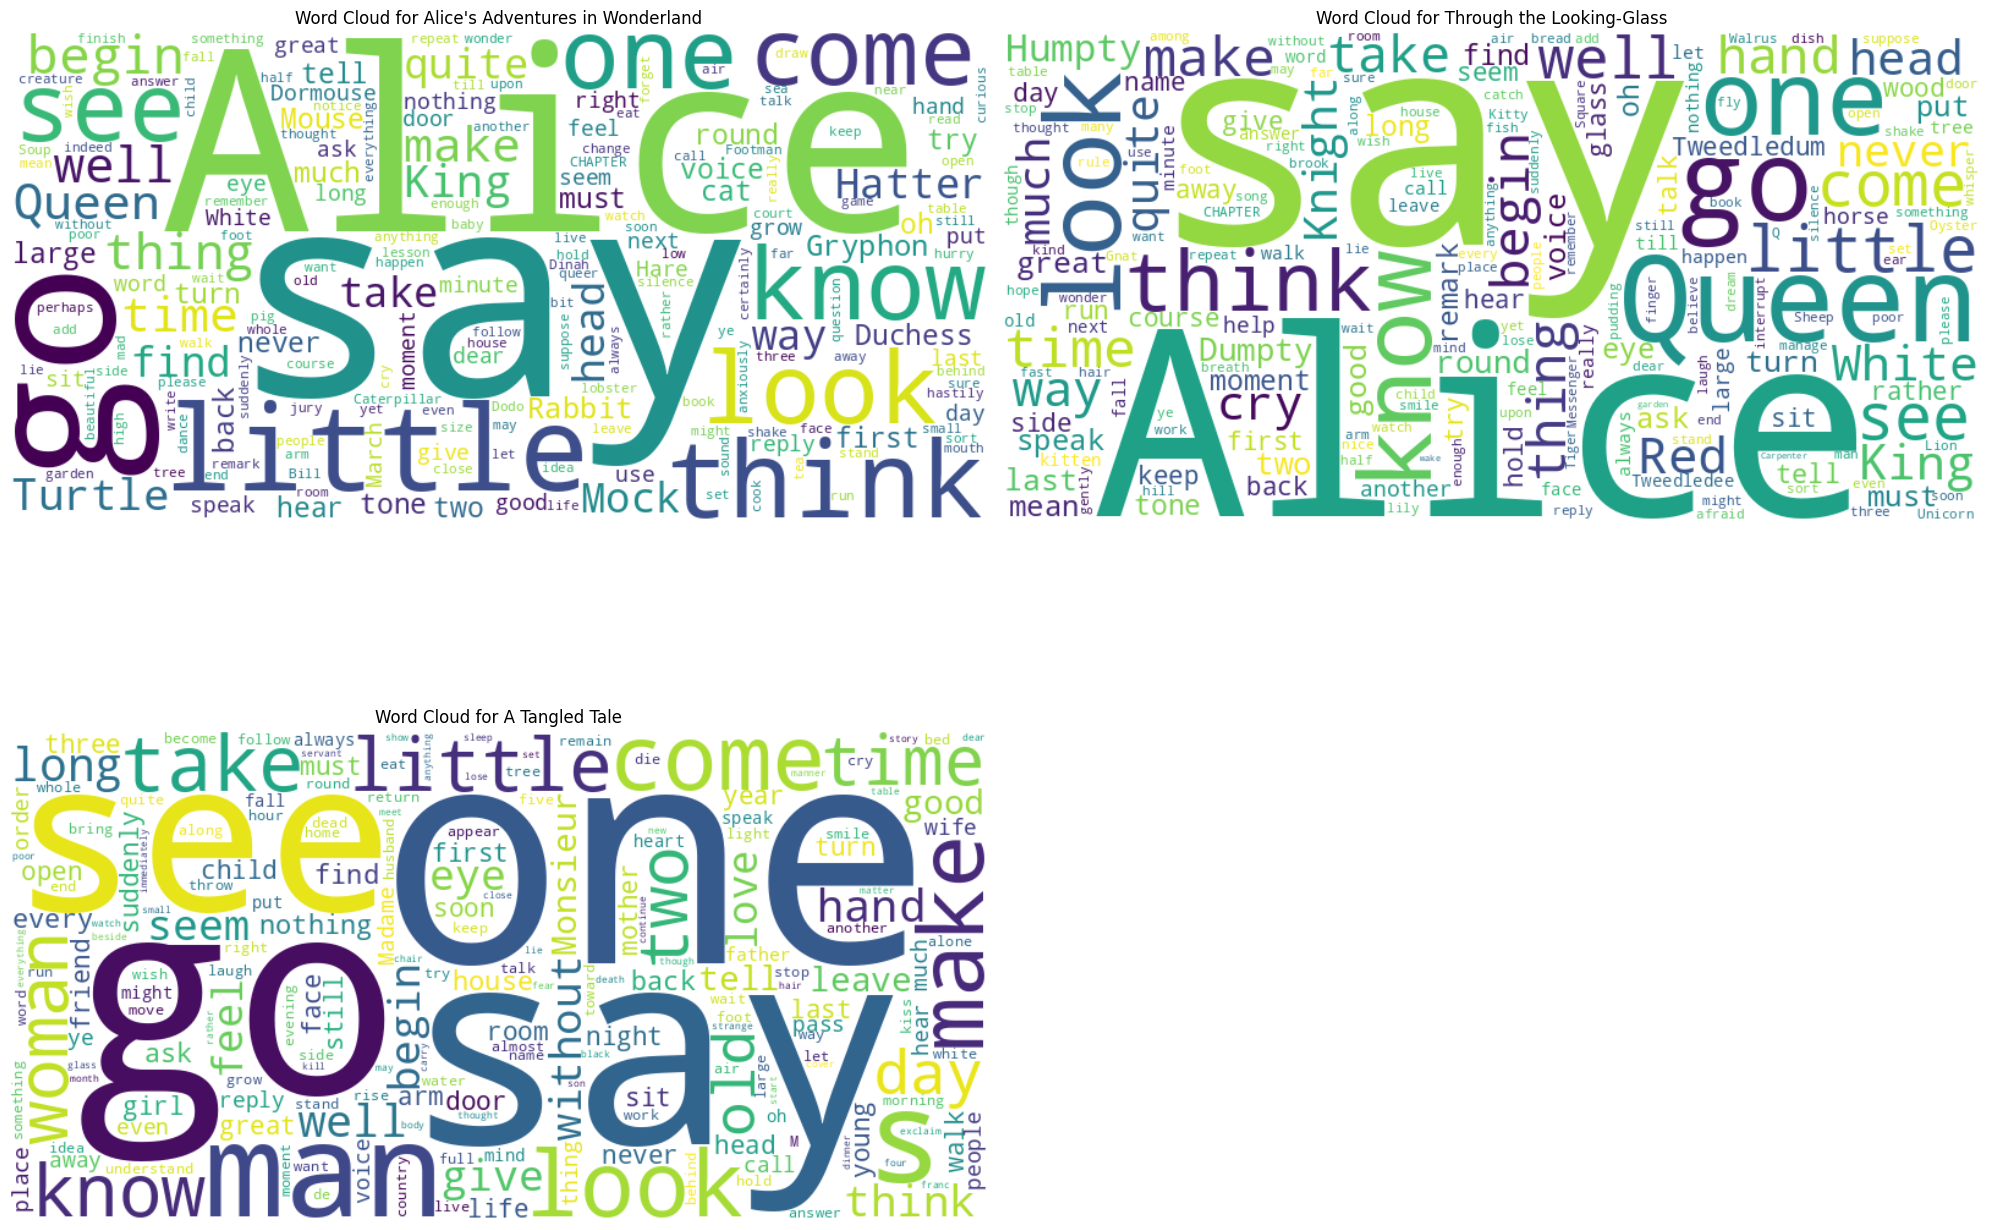

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Using wordcloud and matplotlib, display a word cloud of each book.
print("\n--- Generating Word Clouds ---")

plt.figure(figsize=(20, 15))

for i, (title, lemmas) in enumerate(lemmatized_corpus.items()):
    # Join the lemmatized tokens back into a single string for WordCloud
    text_for_wordcloud = " ".join(lemmas)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        collocations=False # Set to False to avoid treating "new york" as a single word if not desired
    ).generate(text_for_wordcloud)

    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed, 2x2 will work for 3 books
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {title}')
    plt.axis('off')

plt.tight_layout()
plt.show()


### 10. Bag of Words (BoW) Analysis for Most Frequent Words

Now, we'll use the Bag of Words (BoW) model to identify the five most frequent words across all three books. We'll use the lemmatized corpus as it represents the most processed and normalized form of our text, ensuring that variations of a word are counted together.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Prepare the lemmatized texts for CountVectorizer
# CountVectorizer expects a list of strings, where each string is a document.
corpus_for_bow = [" ".join(lemmas) for title, lemmas in lemmatized_corpus.items()]

# Initialize CountVectorizer
# We don't need to specify stop_words here since they were already removed.
vectorizer = CountVectorizer()

# Fit the vectorizer to the corpus and transform the corpus into a BoW matrix
X = vectorizer.fit_transform(corpus_for_bow)

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Create a DataFrame for better visualization of the BoW matrix
bow_df = pd.DataFrame(X.toarray(), columns=feature_names)
bow_df.index = lemmatized_corpus.keys()

# Display the Bag of Words matrix for the first few words and documents
print("\n--- Bag of Words Matrix (sample) ---")
display(bow_df.iloc[:, :20]) # Display first 20 words for brevity

# Interpret the numerical output (document number, index, frequency):
print("\n--- Interpretation of BoW Matrix ---")
print("Each row in the matrix corresponds to a document (book). Each column represents a unique word (feature). The numbers in the cells indicate the frequency of that word in that particular document. For example, `bow_df.loc['Alice\'s Adventures in Wonderland', 'alice']` would give the count of the word 'alice' in 'Alice\'s Adventures in Wonderland'.")

# Calculate overall word frequencies across all documents
word_counts = X.sum(axis=0)

# Create a dictionary of word frequencies
word_freq_dict = dict(zip(feature_names, word_counts.tolist()[0]))

# Sort words by frequency in descending order
sorted_word_freq = sorted(word_freq_dict.items(), key=lambda item: item[1], reverse=True)

# Get the five most frequent words
top_5_frequent_words = sorted_word_freq[:5]

print("\n--- Top 5 Most Frequent Words Across All Books ---")
for word, freq in top_5_frequent_words:
    print(f"Word: '{word}', Frequency: {freq}")



--- Bag of Words Matrix (sample) ---


,000,10,10th,11,12,13,1419,15,15th,16,16th,17,1764,17th,1827,1841,1846,1850,1851,1854
Alice's Adventures in Wonderland,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Through the Looking-Glass,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
A Tangled Tale,1,1,2,1,2,1,1,4,5,1,1,3,2,1,1,1,1,1,2,2



--- Interpretation of BoW Matrix ---
Each row in the matrix corresponds to a document (book). Each column represents a unique word (feature). The numbers in the cells indicate the frequency of that word in that particular document. For example, `bow_df.loc['Alice's Adventures in Wonderland', 'alice']` would give the count of the word 'alice' in 'Alice's Adventures in Wonderland'.

--- Top 5 Most Frequent Words Across All Books ---
Word: 'say', Frequency: 3216
Word: 'one', Frequency: 2909
Word: 'go', Frequency: 2476
Word: 'see', Frequency: 1861
Word: 'would', Frequency: 1746


### 11. Pie Plot of Top 5 Most Frequent Words

To visualize the distribution of the five most frequent words identified by the Bag of Words model, we will create a pie plot. This will clearly show the proportion each of these words contributes to the top 5.


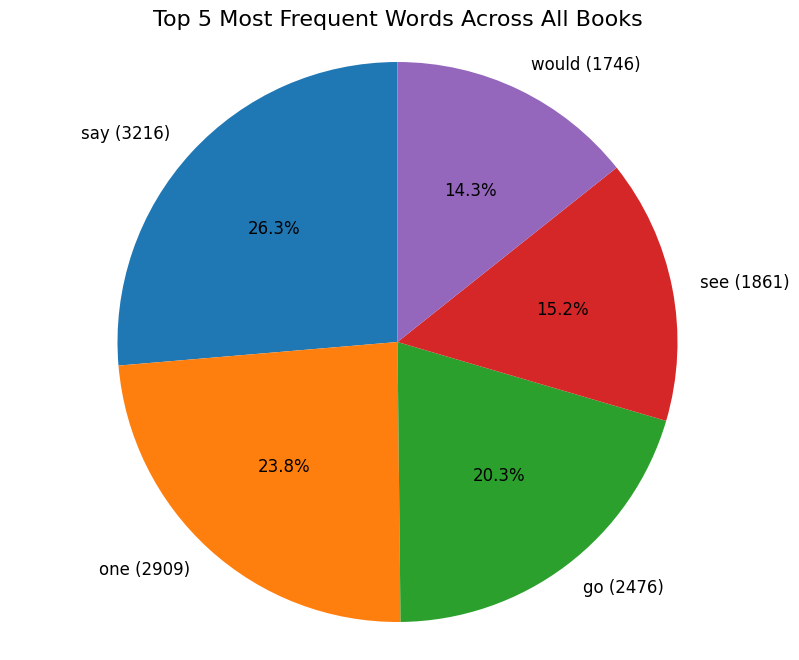

In [ ]:
import matplotlib.pyplot as plt

# Extract words and frequencies for the pie chart
words = [word for word, freq in top_5_frequent_words]
frequencies = [freq for word, freq in top_5_frequent_words]

# Create labels for the pie chart including both word and frequency
labels = [f'{word} ({freq})' for word, freq in top_5_frequent_words]

plt.figure(figsize=(10, 8))
plt.pie(frequencies, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.title('Top 5 Most Frequent Words Across All Books', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


### 12. Solving the Frequency Problem using TF-IDF

As observed, the most frequent words (e.g., 'say', 'one') are often common, less-informative words. To find words that are more significant to a specific document within the corpus, we will use **TF-IDF (Term Frequency-Inverse Document Frequency)**. TF-IDF gives higher weight to words that appear frequently in a document but rarely across the entire corpus.

We will create a new Bag of Words model using `TfidfVectorizer` with `min_df=1` (minimum document frequency) and `max_df=2` (maximum document frequency). `max_df=2` is chosen to filter out terms that appear in more than two documents, thus focusing on terms that are more unique to one or two books rather than being common across all three. `min_df=1` means we include words that appear in at least one document.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with min_df=1 and max_df=2
# This means a word must appear in at least 1 document and in no more than 2 documents.
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)

# Fit the vectorizer to the corpus and transform the corpus into a TF-IDF matrix
X_tfidf = tfidf_vectorizer.fit_transform(corpus_for_bow)

# Get feature names (words)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# Create a DataFrame for better visualization of the TF-IDF matrix
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_feature_names)
tfidf_df.index = lemmatized_corpus.keys()

print("\n--- TF-IDF Matrix (sample) ---")
display(tfidf_df.iloc[:, :20]) # Display first 20 words for brevity

print("\n--- Interpretation of TF-IDF Matrix ---")
print("Each cell contains a TF-IDF score, reflecting how important a word is to a document in the corpus. A higher score means the word is more relevant to that specific document. Words with high frequency in many documents (like common English words) will have lower TF-IDF scores, while words unique to a document will have higher scores.")


--- TF-IDF Matrix (sample) ---


,000,10,10th,11,12,13,1419,15,15th,16,16th,17,1764,17th,1827,1841,1846,1850,1851,1854
Alice's Adventures in Wonderland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Through the Looking-Glass,0.000000,0.011337,0.000000,0.005668,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
A Tangled Tale,0.000447,0.000340,0.000895,0.000340,0.000895,0.000447,0.000447,0.00179,0.002237,0.000447,0.000447,0.001342,0.000895,0.000447,0.000447,0.000447,0.000447,0.000447,0.000895,0.000895



--- Interpretation of TF-IDF Matrix ---
Each cell contains a TF-IDF score, reflecting how important a word is to a document in the corpus. A higher score means the word is more relevant to that specific document. Words with high frequency in many documents (like common English words) will have lower TF-IDF scores, while words unique to a document will have higher scores.


### 13. Pie Plots for Top 5 Most Relevant Words (TF-IDF) for Each Document

Now we will create separate pie plots for each book, displaying its top 5 most relevant words based on their TF-IDF scores. This will highlight the distinctive vocabulary of each text.

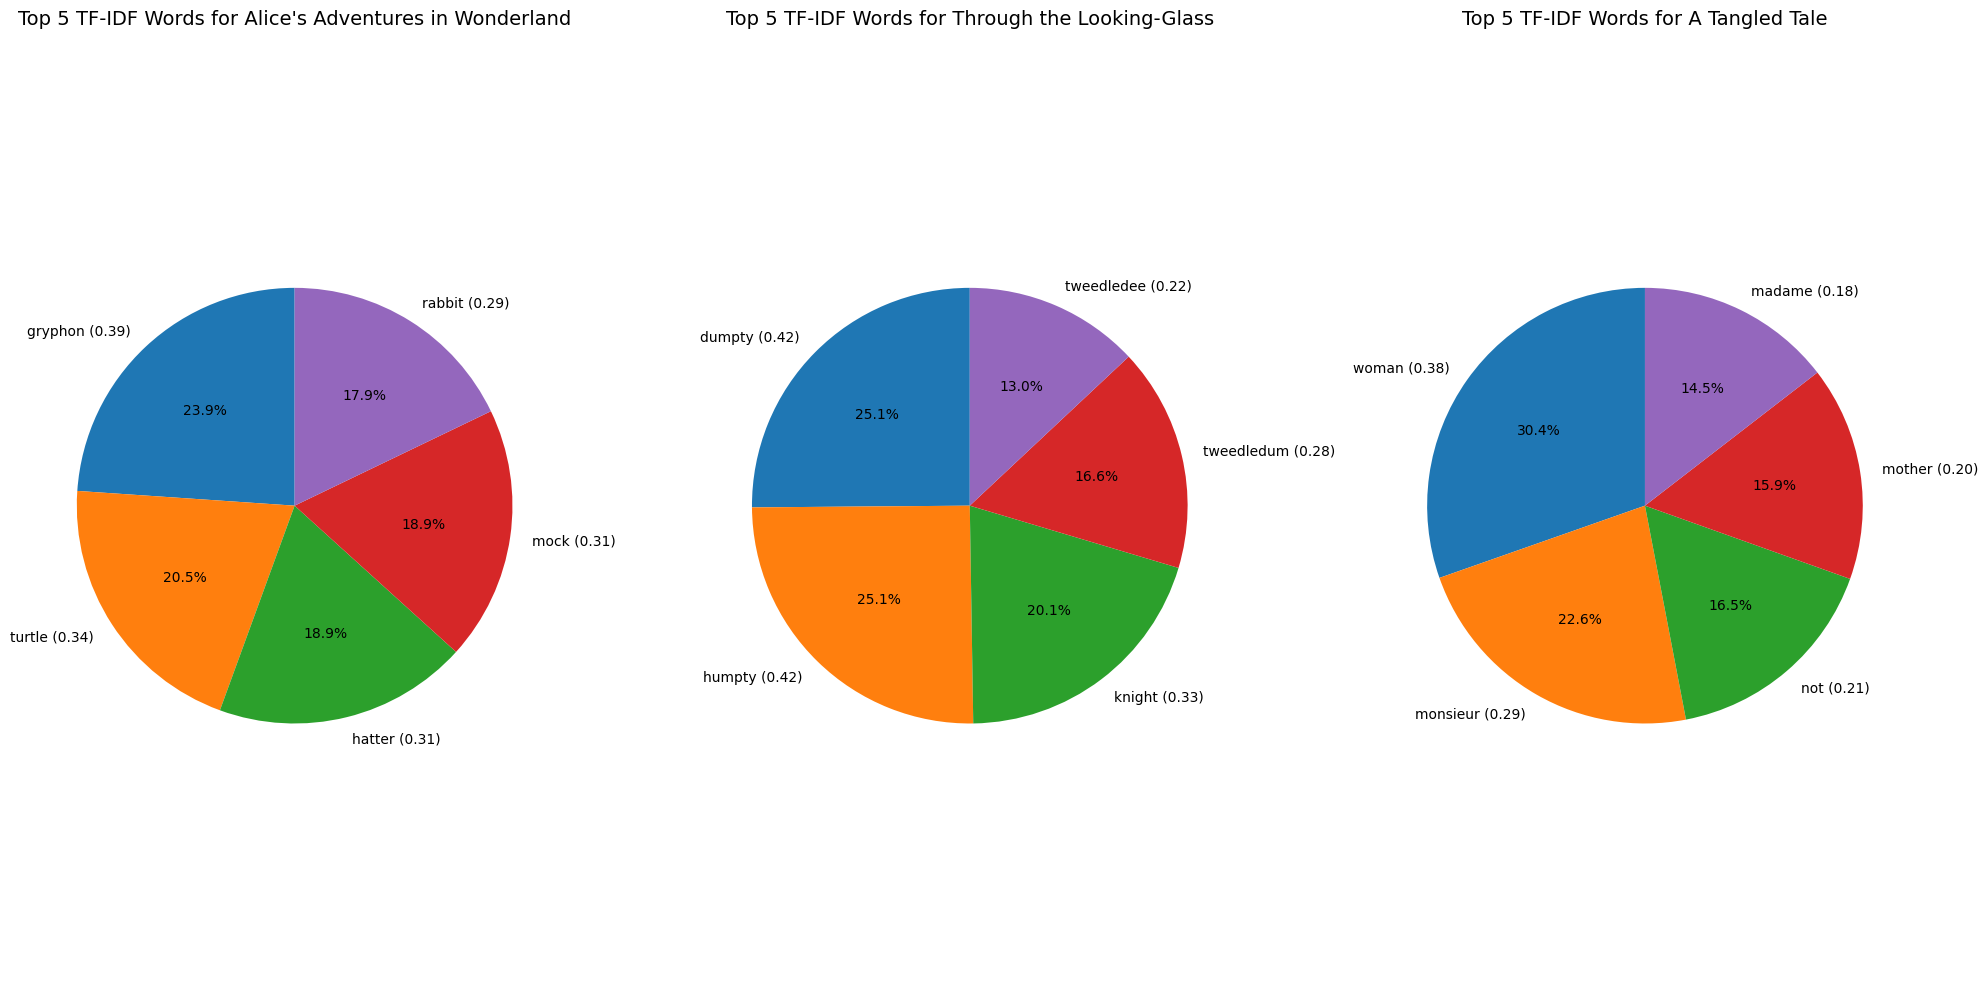

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

for i, (title, row) in enumerate(tfidf_df.iterrows()):
    # Get the top 5 TF-IDF words for the current document
    top_5_tfidf_words = row.nlargest(5)

    words = top_5_tfidf_words.index.tolist()
    scores = top_5_tfidf_words.values.tolist()

    labels = [f'{word} ({score:.2f})' for word, score in zip(words, scores)]

    plt.subplot(1, 3, i + 1) # One row, three columns for three plots
    plt.pie(scores, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
    plt.title(f'Top 5 TF-IDF Words for {title}', fontsize=14)
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()